# FREQ-PRUNE · ResNet-18 · CIFAR-100
**50 base epochs → threshold pruning → 50 fine-tuning epochs.**

Run all cells on a T4 GPU. Drive stores a checkpoint after every epoch, so a disconnected run can resume.
The final cell downloads a ZIP containing both trained models and their reload code; all detailed results stay in Drive.

## Method and assumptions
1. Average **absolute weights across input channels first**, then take one 2D DCT per filter.
2. Square the DCT coefficients and normalize the nine frequency energies.
3. Fit NMF separately per layer with rank 3 and compare normalized fingerprints using cosine similarity ≥ **0.95**.
4. Keep one actual medoid per redundancy group; every pair in a group must pass the similarity checks.
5. Prune each residual block's first convolution, its BatchNorm, and matching inputs of its second convolution.
6. Preserve residual output widths, skip connections, the stem and classifier; copy surviving trained weights exactly.

There is **no entropy score, positional mask, target pruning ratio, or forced channel alignment**.
This is CIFAR-adapted ResNet-18: 3×3 stem, stride 1, no initial max-pool, eight basic blocks.
Rank 3 is an experimental choice, not a consequence of the 3×3 kernel size.

**Extra match check:** folded signed-weight cosine must be ≥ 0.20 and relative folded-bias difference ≤ 0.25.
These configurable guards were discussed in the methodology; 0.95 alone is not the whole removal rule.
Spectral similarity does not prove that channels have the same function; no next-layer weight merging is used.
Complete-link groups prevent a chain of similar pairs from deleting mutually dissimilar filters.

The official training set is split into 45,000 training and 5,000 validation images; test images are used only at the end.
Model selection uses validation accuracy. Each stage completes all 50 epochs, then loads its best validation checkpoint.
This one-seed experiment does not establish superiority over random or magnitude pruning.

CIFAR-100 adaptation: 100 classifier outputs, 50 validation images and 50 BatchNorm calibration images per class, and CIFAR-100 normalization. The total training/validation/calibration counts match the CIFAR-10 experiment. The frequency score and extra signed-weight checks remain identical for this comparison.

## 1. Settings
Use a new `run_name` when changing settings; keep it unchanged to resume this exact experiment.

In [ ]:
CONFIG = {
    "run_name": "freqprune_resnet18_c100_avgabs_r3_sim095_seed42_50plus50_v1",
    "seed": 42, "base_epochs": 50, "finetune_epochs": 50,
    "batch_size": 128, "eval_batch_size": 256, "num_workers": 2,
    "base_lr": 0.1, "finetune_lr": 0.01, "warmup_epochs": 5,
    "momentum": 0.9, "weight_decay": 5e-4,
    "nmf_rank": 3, "similarity_threshold": 0.95,
    "nmf_max_iter": 5000, "nmf_retry_max_iter": 20000, "nmf_tolerance": 1e-4,
    "signed_cosine_min": 0.20, "relative_bias_max": 0.25,
    "validation_per_class": 50, "bn_calibration_per_class": 50,
    "amp": True, "resume": True, "save_to_drive": True,
    "download_models": True,
}
assert 0 < CONFIG["similarity_threshold"] <= 1
assert 1 <= CONFIG["nmf_rank"] <= 9

## 2. Libraries and GPU
Keep Colab's existing PyTorch installation and record package versions with the experiment.

In [ ]:
import os, sys, json, math, time, copy, random, hashlib, shutil, warnings, inspect
import importlib.util, subprocess
from pathlib import Path
from datetime import datetime, timezone
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
needed = {"scipy": "scipy", "sklearn": "scikit-learn"}
missing = [p for m,p in needed.items() if importlib.util.find_spec(m) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from scipy.fft import dctn
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import binomtest
from sklearn.decomposition import NMF
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits
from IPython.display import display
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    raise RuntimeError("Select Runtime > Change runtime type > T4 GPU, then run all again.")
AMP = bool(CONFIG["amp"])
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.use_deterministic_algorithms(True, warn_only=True)
def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_all(CONFIG["seed"])
plt.rcParams.update({"figure.figsize": (9,4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)

GPU: Tesla T4
PyTorch: 2.11.0+cu128 | torchvision: 0.26.0+cu128


## 3. Save folder and protection against accidental overwrites
Connect Drive if prompted; checkpoints, logs and figures are saved inside this run's own folder.

In [ ]:
if CONFIG["save_to_drive"]:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_ROOT = Path("/content/drive/MyDrive/FREQ_PRUNE_Experiments")
else:
    SAVE_ROOT = Path("/content/FREQ_PRUNE_Experiments")
    print("Local runtime files can disappear; download the final archive.")
RUN_DIR = SAVE_ROOT / CONFIG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)
def write_json(value, path):
    path = Path(path); temp = path.with_name(path.name + ".tmp")
    temp.write_text(json.dumps(value, indent=2, allow_nan=False), encoding="utf-8")
    os.replace(temp, path)
def save_torch(value, path):
    path = Path(path); temp = path.with_name(path.name + ".tmp")
    torch.save(value, temp); os.replace(temp, path)
config_path = RUN_DIR / "config.json"
if config_path.exists():
    assert json.loads(config_path.read_text()) == CONFIG, "Use a new run_name for changed settings."
    assert CONFIG["resume"], "Use a new run_name; this folder already contains a run."
else:
    write_json(CONFIG, config_path)
import scipy, sklearn
write_json({"python": sys.version, "torch": torch.__version__, "torchvision": torchvision.__version__,
            "numpy": np.__version__, "scipy": scipy.__version__, "sklearn": sklearn.__version__,
            "gpu": torch.cuda.get_device_name(0), "cuda": torch.version.cuda,
            "cudnn": torch.backends.cudnn.version()},
           RUN_DIR / ("environment_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + ".json"))
print("Results and checkpoints:", RUN_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results and checkpoints: /content/drive/MyDrive/FREQ_PRUNE_Experiments/freqprune_resnet18_c100_avgabs_r3_sim095_seed42_50plus50_v1


## 4. CIFAR-100 with a separate validation set
Random crops and flips are used only for training; all accuracy comparisons use identical evaluation transforms.

In [ ]:
MEAN, STD = (0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761)
train_transform = transforms.Compose([transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
eval_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
data_root = "/content/cifar100_data"
all_train = torchvision.datasets.CIFAR100(data_root, train=True, download=True, transform=train_transform)
all_eval = torchvision.datasets.CIFAR100(data_root, train=True, download=False, transform=eval_transform)
targets = np.asarray(all_train.targets)
rng = np.random.default_rng(CONFIG["seed"])
training_indices, validation_indices = [], []
for label in range(100):
    indices = rng.permutation(np.flatnonzero(targets == label))
    validation_indices.extend(indices[:CONFIG["validation_per_class"]])
    training_indices.extend(indices[CONFIG["validation_per_class"]:])
training_indices, validation_indices = np.sort(training_indices), np.sort(validation_indices)
assert len(set(training_indices) & set(validation_indices)) == 0
assert len(training_indices) + len(validation_indices) == 50000
split_path = RUN_DIR / "split_indices.npz"
if split_path.exists():
    old = np.load(split_path)
    assert np.array_equal(old["train"], training_indices) and np.array_equal(old["validation"], validation_indices)
else:
    np.savez_compressed(split_path, train=training_indices, validation=validation_indices)
TRAIN = Subset(all_train, training_indices)
TRAIN_EVAL = Subset(all_eval, training_indices)
VALIDATION = Subset(all_eval, validation_indices)
calibration_indices = np.concatenate([rng.permutation(training_indices[targets[training_indices] == label])
                                     [:CONFIG["bn_calibration_per_class"]] for label in range(100)])
CALIBRATION = Subset(all_eval, calibration_indices)
np.save(RUN_DIR / "calibration_indices.npy", calibration_indices)
def seed_worker(worker_id):
    seed = torch.initial_seed() % 2**32
    np.random.seed(seed); random.seed(seed)
def make_loader(dataset, training=False, seed=0):
    return DataLoader(dataset, batch_size=CONFIG["batch_size"] if training else CONFIG["eval_batch_size"],
        shuffle=training, num_workers=CONFIG["num_workers"], pin_memory=True,
        generator=torch.Generator().manual_seed(seed), worker_init_fn=seed_worker)
val_loader = make_loader(VALIDATION)
calibration_loader = make_loader(CALIBRATION)
CLASSES = all_train.classes
write_json({"dataset": "CIFAR100", "train":len(TRAIN), "validation":len(VALIDATION),
            "test_reserved":10000, "classes":CLASSES, "mean":MEAN, "std":STD,
            "split_sha256":hashlib.sha256(training_indices.tobytes()+validation_indices.tobytes()).hexdigest()},
           RUN_DIR / "dataset.json")
print("Train:",len(TRAIN), "| Validation:",len(VALIDATION), "| Test reserved: 10000")
assert len(CLASSES)==100 and len(TRAIN)==45000 and len(VALIDATION)==5000
assert len(CALIBRATION)==5000
assert np.all(np.bincount(targets[validation_indices], minlength=100)==50)


100%|██████████| 169M/169M [39:43<00:00, 70.9kB/s]


Train: 45000 | Validation: 5000 | Test reserved: 10000


## 5. ResNet-18 with independently resizable internal channels
The first convolution in each block can become narrower while the residual addition keeps its original shape.

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, inputs, outputs, hidden, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(inputs, hidden, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(hidden)
        self.relu1 = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(hidden, outputs, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(outputs)
        self.shortcut = nn.Identity() if stride == 1 and inputs == outputs else nn.Sequential(
            nn.Conv2d(inputs, outputs, 1, stride=stride, bias=False), nn.BatchNorm2d(outputs))
        self.relu2 = nn.ReLU(inplace=False)
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu1(self.bn1(self.conv1(x)))
        return self.relu2(self.bn2(self.conv2(out)) + identity)

class ResNet18CIFAR(nn.Module):
    def __init__(self, hidden_widths=None, num_classes=100, base_width=64):
        super().__init__()
        outputs = [base_width,base_width,2*base_width,2*base_width,
                   4*base_width,4*base_width,8*base_width,8*base_width]
        self.hidden_widths = list(outputs if hidden_widths is None else hidden_widths)
        assert len(self.hidden_widths) == 8 and min(self.hidden_widths) >= 1
        self.num_classes, self.base_width = num_classes, base_width
        self.stem = nn.Sequential(nn.Conv2d(3,base_width,3,padding=1,bias=False),
                                  nn.BatchNorm2d(base_width), nn.ReLU(inplace=False))
        blocks, inputs = [], base_width
        for index, (width,hidden) in enumerate(zip(outputs,self.hidden_widths)):
            stride = 2 if index in (2,4,6) else 1
            blocks.append(BasicBlock(inputs,width,hidden,stride)); inputs = width
        self.blocks = nn.ModuleList(blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(inputs,num_classes)
        for module in self.modules():
            if isinstance(module,nn.Conv2d):
                nn.init.kaiming_normal_(module.weight,mode="fan_out",nonlinearity="relu")
            elif isinstance(module,nn.BatchNorm2d):
                nn.init.ones_(module.weight); nn.init.zeros_(module.bias)
    def forward(self,x):
        x = self.stem(x)
        for block in self.blocks: x = block(x)
        return self.fc(self.pool(x).flatten(1))
    def architecture(self):
        return {"hidden_widths":self.hidden_widths, "num_classes":self.num_classes, "base_width":self.base_width}

def model_payload(model, **extra):
    return {"architecture":model.architecture(), "config":CONFIG,
            "model_state_dict":{k:v.detach().cpu().clone() for k,v in model.state_dict().items()}, **extra}
def load_model(path, device=DEVICE):
    # Load only this experiment's trusted checkpoints.
    saved = torch.load(path,map_location="cpu",weights_only=False)
    model = ResNet18CIFAR(**saved["architecture"])
    model.load_state_dict(saved["model_state_dict"],strict=True)
    return model.to(device), saved
seed_all(CONFIG["seed"])
base_model = ResNet18CIFAR().to(DEVICE)
print("Base parameters:", f"{sum(p.numel() for p in base_model.parameters()):,}")
print("Prunable internal widths:",base_model.hidden_widths)

Base parameters: 11,220,132
Prunable internal widths: [64, 64, 128, 128, 256, 256, 512, 512]


## 6. Training, evaluation and resumable checkpoints
Every epoch saves loss, top-1/top-5 accuracy, learning rate and time; the optimizer and random states are saved for resuming.

In [ ]:
criterion = nn.CrossEntropyLoss()
def rng_state():
    return {"python":random.getstate(), "numpy":np.random.get_state(),
            "torch":torch.get_rng_state(), "cuda":torch.cuda.get_rng_state_all()}
def restore_rng(state):
    random.setstate(state["python"]); np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"]); torch.cuda.set_rng_state_all(state["cuda"])
def run_epoch(model, loader, optimizer=None, scaler=None, predictions=False):
    training = optimizer is not None
    model.train(training)
    loss_sum,correct1,correct5,total = 0.0,0,0,0
    labels_saved, probabilities = [],[]
    with torch.set_grad_enabled(training):
        for images,labels in loader:
            images,labels = images.to(DEVICE,non_blocking=True),labels.to(DEVICE,non_blocking=True)
            if training: optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda",enabled=AMP):
                logits=model(images); loss=criterion(logits,labels)
            if not torch.isfinite(loss): raise FloatingPointError("Non-finite loss; last checkpoint is safe.")
            if training:
                scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            n=labels.size(0); top=logits.detach().topk(5,dim=1).indices
            loss_sum+=loss.item()*n; total+=n
            correct1+=(top[:,0]==labels).sum().item()
            correct5+=(top==labels[:,None]).any(dim=1).sum().item()
            if predictions:
                labels_saved.append(labels.cpu().numpy())
                probabilities.append(logits.detach().float().softmax(dim=1).cpu().numpy())
    metrics={"loss":loss_sum/total,"top1":100*correct1/total,"top5":100*correct5/total,"images":total}
    return (metrics,np.concatenate(labels_saved),np.concatenate(probabilities)) if predictions else metrics
def learning_rate(epoch,epochs,initial,warmup):
    if epoch<=warmup: return initial*epoch/warmup
    fraction=(epoch-warmup-1)/max(1,epochs-warmup-1)
    return initial*(0.01+0.99*0.5*(1+math.cos(math.pi*fraction)))
def train_stage(model,stage,epochs,initial_lr,warmup=0):
    folder=RUN_DIR/stage; folder.mkdir(exist_ok=True)
    best_path,last_path=folder/"best.pt",folder/"last.pt"
    model=model.to(DEVICE)
    optimizer=torch.optim.SGD(model.parameters(),lr=initial_lr,momentum=CONFIG["momentum"],weight_decay=CONFIG["weight_decay"])
    scaler=torch.amp.GradScaler("cuda",enabled=AMP)
    history,start,best_score,best_epoch=[],1,-1.0,0
    if CONFIG["resume"] and last_path.exists():
        saved=torch.load(last_path,map_location="cpu",weights_only=False)
        assert saved["config"]==CONFIG and saved["architecture"]==model.architecture()
        model.load_state_dict(saved["model_state_dict"])
        optimizer.load_state_dict(saved["optimizer_state_dict"]); scaler.load_state_dict(saved["scaler_state_dict"])
        history,start=saved["history"],saved["epoch"]+1
        best_score,best_epoch=saved["best_validation_top1"],saved["best_epoch"]
        restore_rng(saved["rng_state"])
        print(f"{stage}: resuming after epoch {start-1}.")
    else:
        seed_all(CONFIG["seed"]+(1000 if stage=="finetune" else 0))
        initial=run_epoch(model,val_loader); best_score=initial["top1"]
        save_torch(model_payload(model,epoch=0,validation=initial),best_path)
    for epoch in range(start,epochs+1):
        began=time.perf_counter()
        lr=learning_rate(epoch,epochs,initial_lr,warmup)
        for group in optimizer.param_groups: group["lr"]=lr
        loader=make_loader(TRAIN,True,CONFIG["seed"]+epoch+10000*(stage=="finetune"))
        train=run_epoch(model,loader,optimizer,scaler)
        val=run_epoch(model,val_loader)
        row={"epoch":epoch,"lr":lr,"seconds":time.perf_counter()-began,
             **{f"train_{k}":v for k,v in train.items()},**{f"validation_{k}":v for k,v in val.items()}}
        history.append(row)
        if val["top1"]>best_score:
            best_score,best_epoch=val["top1"],epoch
            save_torch(model_payload(model,epoch=epoch,validation=val),best_path)
        save_torch(model_payload(model,epoch=epoch,history=history,best_epoch=best_epoch,
            best_validation_top1=best_score,optimizer_state_dict=optimizer.state_dict(),
            scaler_state_dict=scaler.state_dict(),rng_state=rng_state()),last_path)
        pd.DataFrame(history).to_csv(folder/"history.csv",index=False)
        write_json({"stage":stage,"epoch":epoch,"epochs":epochs,"validation_top1":val["top1"],"complete":False},RUN_DIR/"status.json")
        print(f"{stage} {epoch:02d}/{epochs} | train {train['top1']:.2f}% | val {val['top1']:.2f}% | "
              f"val loss {val['loss']:.4f} | lr {lr:.5f} | {row['seconds']:.1f}s",flush=True)
    model,saved=load_model(best_path)
    print(f"Selected {stage} epoch {saved['epoch']}; validation {saved['validation']['top1']:.2f}%.")
    return model,history

## 7. Average absolute weights → DCT → NMF → similarity groups
NMF bases are normalized with compensating coefficients before cosine comparisons; unstable NMF layers remain unpruned and are reported.
All pairs in each group must pass both spectral and signed-weight checks; the medoid is retained and ties use the lowest channel index.

In [ ]:
EPS=1e-12
def frequency_description(weights):
    weights=np.asarray(weights,dtype=np.float64)
    averaged=np.abs(weights).mean(axis=1)  # Average FIRST: one spatial map per output filter.
    dct=dctn(averaged,type=2,axes=(-2,-1),norm="ortho")
    energy=np.square(dct).reshape(len(weights),-1)
    totals=energy.sum(axis=1)
    valid=totals>EPS
    probability=np.zeros_like(energy)
    probability[valid]=energy[valid]/totals[valid,None]
    return probability,valid,averaged

def nmf_fingerprints(probability):
    rank=min(CONFIG["nmf_rank"],*probability.shape)
    attempts=[]
    for limit in [CONFIG["nmf_max_iter"],CONFIG["nmf_retry_max_iter"]]:
        with warnings.catch_warnings(record=True) as caught,threadpool_limits(limits=2):
            warnings.simplefilter("always",ConvergenceWarning)
            nmf=NMF(n_components=rank,init="nndsvda",random_state=CONFIG["seed"],
                    max_iter=limit,tol=CONFIG["nmf_tolerance"])
            mixing=nmf.fit_transform(probability)
        converged=not any(issubclass(w.category,ConvergenceWarning) for w in caught)
        attempts.append({"max_iter":limit,"iterations":int(nmf.n_iter_),"converged":converged})
        if converged: break
    bases=nmf.components_.copy()
    scale=np.maximum(np.linalg.norm(bases,axis=1),EPS)
    bases/=scale[:,None]; mixing*=scale[None,:]
    error=float(np.linalg.norm(probability-mixing@bases)/max(np.linalg.norm(probability),EPS))
    fingerprints=mixing/np.maximum(np.linalg.norm(mixing,axis=1,keepdims=True),EPS)
    return fingerprints,bases,{"rank":rank,"converged":converged,"relative_reconstruction_error":error,"attempts":attempts}

def group_channels(similarity,eligible):
    n=len(similarity)
    if n==1: return [[0]],[0]
    # Complete linkage requires every pair in a group to satisfy the threshold.
    distance=np.where(eligible,np.clip(1-similarity,0,2),2.0)
    distance=(distance+distance.T)/2; np.fill_diagonal(distance,0)
    hierarchy=linkage(squareform(distance,checks=True),method="complete")
    labels=fcluster(hierarchy,t=1-CONFIG["similarity_threshold"]+1e-12,criterion="distance")
    groups=[np.flatnonzero(labels==label).tolist() for label in np.unique(labels)]
    groups.sort(key=lambda group:min(group))
    representatives=[]
    for group in groups:
        within=similarity[np.ix_(group,group)]
        representatives.append(group[int(np.argmin((1-within).sum(axis=1)))])
        for a in group:
            for b in group:
                assert a==b or (eligible[a,b] and similarity[a,b]>=CONFIG["similarity_threshold"]-1e-10)
    return groups,representatives

def analyse_filters(weights,bn):
    raw=np.asarray(weights,dtype=np.float64)
    probability,valid,averaged=frequency_description(raw)
    n=len(raw)
    if valid.sum()<CONFIG["nmf_rank"]:
        groups=[[i] for i in range(n)]
        return list(range(n)),groups,[],{"converged":False,"reason":"Too few nonzero filters","original_channels":n,
            "kept_channels":n,"removed_channels":0,"spectral_pairs":0,"eligible_pairs":0}, {"probability":probability}
    fingerprints,bases,diagnostics=nmf_fingerprints(probability)
    similarity=np.clip(fingerprints@fingerprints.T,-1,1)
    factor=bn.weight.detach().cpu().double().numpy()/np.sqrt(bn.running_var.detach().cpu().double().numpy()+bn.eps)
    bias=bn.bias.detach().cpu().double().numpy()-factor*bn.running_mean.detach().cpu().double().numpy()
    effective=(raw*factor[:,None,None,None]).reshape(n,-1)
    norms=np.linalg.norm(effective,axis=1)
    unit=effective/np.maximum(norms[:,None],EPS)
    signed=np.clip(unit@unit.T,-1,1)
    relative_bias=np.abs(bias[:,None]-bias[None,:])/np.maximum((norms[:,None]+norms[None,:])/2,EPS)
    valid=valid & (norms>EPS) & (np.linalg.norm(fingerprints,axis=1)>EPS)
    spectral=(similarity>=CONFIG["similarity_threshold"]) & valid[:,None] & valid[None,:]
    eligible=spectral & (signed>=CONFIG["signed_cosine_min"]) & (relative_bias<=CONFIG["relative_bias_max"])
    if not diagnostics["converged"]: eligible[:]=False
    groups,representatives=group_channels(similarity,eligible)
    kept=sorted(representatives)
    decisions=[]
    for group,representative in zip(groups,representatives):
        for candidate in group:
            if candidate!=representative:
                decisions.append({"removed":candidate,"representative":representative,"group_size":len(group),
                    "nmf_cosine_similarity":float(similarity[candidate,representative]),
                    "signed_cosine":float(signed[candidate,representative]),
                    "relative_bias_difference":float(relative_bias[candidate,representative])})
    assert all(d["representative"] in kept and d["removed"] not in kept for d in decisions)
    diagnostics.update({"original_channels":n,"kept_channels":len(kept),"removed_channels":n-len(kept),
        "spectral_pairs":int(np.triu(spectral,1).sum()),"eligible_pairs":int(np.triu(eligible,1).sum()),
        "invalid_filters_retained":int((~valid).sum()),"removal_percent":100*(n-len(kept))/n})
    return kept,groups,decisions,diagnostics,{"averaged_abs_weights":averaged,"probability":probability,
        "fingerprints":fingerprints,"bases":bases,"nmf_similarity":similarity,"signed_similarity":signed}

def build_plan(model):
    plan,rows,all_groups,all_decisions,all_diagnostics={},[],{},[],{}
    folder=RUN_DIR/"spectral_diagnostics"; folder.mkdir(exist_ok=True)
    for index,block in enumerate(model.blocks):
        weights=block.conv1.weight.detach().cpu().numpy()
        kept,groups,decisions,diagnostics,arrays=analyse_filters(weights,block.bn1)
        plan[str(index)]=kept; all_groups[str(index)]=groups; all_diagnostics[str(index)]=diagnostics
        row={"block":index+1,**{k:v for k,v in diagnostics.items() if k!="attempts"}}
        rows.append(row)
        all_decisions.extend({"block":index+1,**d} for d in decisions)
        np.savez_compressed(folder/f"block_{index+1}.npz",**arrays)
        print(f"Block {index+1}: {weights.shape[0]} -> {len(kept)} channels; NMF converged: {diagnostics['converged']}")
    write_json(plan,RUN_DIR/"kept_channels.json"); write_json(all_groups,RUN_DIR/"groups.json")
    write_json(all_diagnostics,RUN_DIR/"nmf_diagnostics.json")
    write_json(all_decisions,RUN_DIR/"pruning_decisions.json")
    pd.DataFrame(rows).to_csv(RUN_DIR/"layer_pruning.csv",index=False)
    return plan,pd.DataFrame(rows)

## 8. Remove channels and test the mathematics before training
Tests cover the exact averaging order, a sign-reversed filter, a similarity chain, residual connections, saved architecture and a real gradient update.

In [ ]:
def make_pruned_model(original,plan):
    small=ResNet18CIFAR([len(plan[str(i)]) for i in range(8)],original.num_classes,original.base_width)
    state={k:v.detach().cpu().clone() for k,v in original.state_dict().items()}
    for index in range(8):
        keep=torch.tensor(plan[str(index)],dtype=torch.long)
        prefix=f"blocks.{index}."
        state[prefix+"conv1.weight"]=state[prefix+"conv1.weight"][keep]
        for name in ["weight","bias","running_mean","running_var"]:
            state[prefix+"bn1."+name]=state[prefix+"bn1."+name][keep]
        state[prefix+"conv2.weight"]=state[prefix+"conv2.weight"][:,keep]
    small.load_state_dict(state,strict=True)
    return small.to(DEVICE)

@torch.no_grad()
def check_surgery(original,small,plan,sample):
    original.eval(); small.eval(); handles=[]
    for index,block in enumerate(original.blocks):
        mask=torch.zeros(1,block.conv1.out_channels,1,1,device=DEVICE)
        mask[:,plan[str(index)]]=1
        handles.append(block.relu1.register_forward_hook(lambda module,args,out,mask=mask:out*mask))
    try:
        expected=original(sample.to(DEVICE)); actual=small(sample.to(DEVICE))
        torch.testing.assert_close(actual,expected,rtol=3e-4,atol=3e-5)
        error=float((actual-expected).abs().max())
    finally:
        for handle in handles: handle.remove()
    return error

def small_checks():
    state=rng_state()
    try:
        seed_all(123)
        weights=np.random.default_rng(123).normal(size=(12,4,3,3))
        weights[1]=weights[0]; weights[2]=-weights[0]
        p,valid,averaged=frequency_description(weights)
        assert np.allclose(averaged,np.abs(weights).mean(axis=1))
        assert np.allclose(p.sum(axis=1),1) and np.allclose(p[0],p[2])
        assert np.allclose((dctn(averaged,axes=(-2,-1),norm="ortho")**2).sum(),(averaged**2).sum())
        # Duplicate positive copies group together; the negative copy cannot join them.
        kept,groups,decisions,diag,_=analyse_filters(weights,nn.BatchNorm2d(12))
        assert diag["converged"]
        assert any(0 in g and 1 in g for g in groups)
        assert not any(0 in g and 2 in g for g in groups)
        # A-B and B-C matches must not imply an A-C match.
        sim=np.array([[1,.96,.90],[.96,1,.96],[.90,.96,1]])
        chain_groups,_=group_channels(sim,sim>=CONFIG["similarity_threshold"])
        assert max(map(len,chain_groups))==2
        tiny=ResNet18CIFAR(base_width=4).to(DEVICE)
        with torch.no_grad():
            for m in tiny.modules():
                if isinstance(m,nn.BatchNorm2d):
                    m.weight.uniform_(.5,1.5); m.bias.uniform_(-.2,.2)
                    m.running_mean.uniform_(-.3,.3); m.running_var.uniform_(.5,1.5)
        plan={str(i):list(range(0,b.conv1.out_channels,2)) for i,b in enumerate(tiny.blocks)}
        small=make_pruned_model(tiny,plan)
        error=check_surgery(tiny,small,plan,torch.randn(4,3,32,32,device=DEVICE))
        payload=model_payload(small); rebuilt=ResNet18CIFAR(**payload["architecture"])
        rebuilt.load_state_dict(payload["model_state_dict"],strict=True)
        small.train(); before=small.blocks[0].conv1.weight.detach().clone()
        opt=torch.optim.SGD(small.parameters(),lr=.01)
        loss=criterion(small(torch.randn(4,3,32,32,device=DEVICE)),torch.arange(4,device=DEVICE))
        opt.zero_grad(); loss.backward(); opt.step()
        assert not torch.equal(before,small.blocks[0].conv1.weight)
        result={"passed":True,"surgery_max_error":error,"checks":["average before DCT","DCT energy", "positive and negative copies",
                 "no transitive grouping","residual channel removal","reload","gradient update"]}
        write_json(result,RUN_DIR/"implementation_checks.json")
        print("All small implementation checks passed.",result)
    finally:
        restore_rng(state)
small_checks()

All small implementation checks passed. {'passed': True, 'surgery_max_error': 2.384185791015625e-06, 'checks': ['average before DCT', 'DCT energy', 'positive and negative copies', 'no transitive grouping', 'residual channel removal', 'reload', 'gradient update']}


## 9. Train and save the base model for 50 epochs
The best and last checkpoints are both saved; the best validation checkpoint is used for pruning.

In [ ]:
base_model,base_history=train_stage(base_model,"base",CONFIG["base_epochs"],CONFIG["base_lr"],CONFIG["warmup_epochs"])
_,base_saved=load_model(RUN_DIR/"base/best.pt",device="cpu")
save_torch(base_saved,RUN_DIR/"base_model.pt")
base_validation=run_epoch(base_model,val_loader)
write_json(base_validation,RUN_DIR/"base_validation.json")
print("BASE MODEL SAVED:",RUN_DIR/"base_model.pt")
print("Base validation:",base_validation)

base 01/50 | train 11.38% | val 16.86% | val loss 3.5050 | lr 0.02000 | 25.1s
base 02/50 | train 20.94% | val 25.18% | val loss 2.9613 | lr 0.04000 | 26.3s
base 03/50 | train 30.18% | val 33.50% | val loss 2.6564 | lr 0.06000 | 28.5s
base 04/50 | train 37.88% | val 39.34% | val loss 2.3169 | lr 0.08000 | 27.2s
base 05/50 | train 43.47% | val 38.80% | val loss 2.3914 | lr 0.10000 | 26.7s
base 06/50 | train 48.97% | val 44.34% | val loss 2.1242 | lr 0.10000 | 26.4s
base 07/50 | train 52.44% | val 47.54% | val loss 1.9713 | lr 0.09987 | 28.3s
base 08/50 | train 54.94% | val 51.28% | val loss 1.7481 | lr 0.09950 | 27.6s
base 09/50 | train 56.98% | val 49.34% | val loss 1.8868 | lr 0.09887 | 27.9s
base 10/50 | train 58.73% | val 47.28% | val loss 1.9706 | lr 0.09799 | 26.3s
base 11/50 | train 59.77% | val 48.06% | val loss 2.0094 | lr 0.09688 | 26.4s
base 12/50 | train 61.01% | val 51.68% | val loss 1.8119 | lr 0.09553 | 25.7s
base 13/50 | train 62.07% | val 55.18% | val loss 1.6620 | lr 0.

## 10. Prune by similarity and verify the actual trained network
There is no fixed removal percentage; the table reports what the 0.95 threshold and signed checks actually remove.

In [ ]:
pruned_path=RUN_DIR/"pruned_before_finetune.pt"
if pruned_path.exists() and CONFIG["resume"]:
    plan=json.loads((RUN_DIR/"kept_channels.json").read_text())
    layer_results=pd.read_csv(RUN_DIR/"layer_pruning.csv")
    pruned_model,_=load_model(pruned_path)
else:
    plan,layer_results=build_plan(base_model)
    pruned_model=make_pruned_model(base_model,plan)
    sample=torch.stack([TRAIN_EVAL[i][0] for i in range(4)]).to(DEVICE)
    surgery_error=check_surgery(base_model,pruned_model,plan,sample)
    save_torch(model_payload(pruned_model,stage="pruned_before_finetune",surgery_max_error=surgery_error),pruned_path)
    print("Trained network removal check passed; maximum output difference:",surgery_error)
pruned_validation=run_epoch(pruned_model,val_loader)
write_json(pruned_validation,RUN_DIR/"pruned_validation.json")
display(layer_results[["block","original_channels","kept_channels","removed_channels","spectral_pairs","eligible_pairs","converged"]])
print("Validation before pruning:",base_validation["top1"])
print("Validation after pruning:",pruned_validation["top1"])
removed=int(layer_results.removed_channels.sum())
print("Channels removed:",removed,"out of",int(layer_results.original_channels.sum()),"eligible internal channels.")
if removed==0: print("No channels were removed; this run cannot demonstrate compression.")
base_model=base_model.cpu(); torch.cuda.empty_cache()

Block 1: 64 -> 64 channels; NMF converged: False
Block 2: 64 -> 35 channels; NMF converged: True
Block 3: 128 -> 77 channels; NMF converged: True
Block 4: 128 -> 80 channels; NMF converged: True
Block 5: 256 -> 156 channels; NMF converged: True
Block 6: 256 -> 177 channels; NMF converged: True
Block 7: 512 -> 364 channels; NMF converged: True
Block 8: 512 -> 389 channels; NMF converged: True
Trained network removal check passed; maximum output difference: 2.384185791015625e-06


,block,original_channels,kept_channels,removed_channels,spectral_pairs,eligible_pairs,converged
0,1,64,64,0,1610,0,False
1,2,64,35,29,2016,122,True
2,3,128,77,51,8128,201,True
3,4,128,80,48,8128,175,True
4,5,256,156,100,32640,448,True
5,6,256,177,79,32640,209,True
6,7,512,364,148,130816,368,True
7,8,512,389,123,130816,271,True


Validation before pruning: 75.9
Validation after pruning: 11.86
Channels removed: 578 out of 1920 eligible internal channels.


## 11. Measure the effect of refreshing BatchNorm statistics
This diagnostic uses 5,000 training images without gradient updates; fine-tuning below still starts from the original pruned checkpoint.

In [ ]:
@torch.no_grad()
def recalibrate_bn(model,loader):
    model.eval(); changed=[]
    for module in model.modules():
        if isinstance(module,nn.BatchNorm2d):
            changed.append((module,module.momentum))
            module.reset_running_stats(); module.momentum=None; module.train()
    try:
        for images,_ in loader:
            with torch.amp.autocast(device_type="cuda",enabled=AMP): model(images.to(DEVICE))
    finally:
        for module,momentum in changed: module.momentum=momentum
        model.eval()
bn_model=copy.deepcopy(pruned_model)
recalibrate_bn(bn_model,calibration_loader)
bn_validation=run_epoch(bn_model,val_loader)
save_torch(model_payload(bn_model,stage="bn_recalibrated",validation=bn_validation),RUN_DIR/"pruned_bn_recalibrated.pt")
write_json(bn_validation,RUN_DIR/"bn_recalibrated_validation.json")
print("Validation before BN refresh:",pruned_validation["top1"],"| after:",bn_validation["top1"])
del bn_model; torch.cuda.empty_cache()

Validation before BN refresh: 11.86 | after: 61.18


## 12. Fine-tune for 50 epochs and save the final model
Surviving learned weights continue training with a fresh optimizer and a smaller learning rate.

In [ ]:
pruned_model,finetune_history=train_stage(pruned_model,"finetune",CONFIG["finetune_epochs"],CONFIG["finetune_lr"])
_,final_saved=load_model(RUN_DIR/"finetune/best.pt",device="cpu")
save_torch(final_saved,RUN_DIR/"finetuned_model.pt")
final_validation=run_epoch(pruned_model,val_loader)
print("FINE-TUNED MODEL SAVED:",RUN_DIR/"finetuned_model.pt")
print("Final validation:",final_validation)

finetune 01/50 | train 94.42% | val 69.34% | val loss 1.2454 | lr 0.01000 | 26.6s
finetune 02/50 | train 95.31% | val 69.18% | val loss 1.2699 | lr 0.00999 | 25.2s
finetune 03/50 | train 96.07% | val 70.36% | val loss 1.1916 | lr 0.00996 | 26.1s
finetune 04/50 | train 96.72% | val 70.72% | val loss 1.2055 | lr 0.00991 | 27.2s
finetune 05/50 | train 96.84% | val 71.50% | val loss 1.1925 | lr 0.00984 | 27.8s
finetune 06/50 | train 97.32% | val 70.24% | val loss 1.2123 | lr 0.00975 | 27.5s
finetune 07/50 | train 97.47% | val 70.82% | val loss 1.2056 | lr 0.00964 | 25.7s
finetune 08/50 | train 97.76% | val 70.78% | val loss 1.1928 | lr 0.00951 | 25.3s
finetune 09/50 | train 97.59% | val 70.98% | val loss 1.1991 | lr 0.00936 | 26.3s
finetune 10/50 | train 98.05% | val 72.28% | val loss 1.1689 | lr 0.00920 | 26.1s
finetune 11/50 | train 98.32% | val 73.02% | val loss 1.1365 | lr 0.00902 | 26.8s
finetune 12/50 | train 98.69% | val 73.20% | val loss 1.1172 | lr 0.00882 | 25.9s
finetune 13/50 |

## 13. Final accuracy, per-class results and confidence quality
All models use the same official test images; test predictions are never used to choose checkpoints or pruning settings.
ECE measures confidence mismatch (lower is better); its value depends on the 15 fixed confidence bins.

In [ ]:
test_data=torchvision.datasets.CIFAR100(data_root,train=False,download=False,transform=eval_transform)
test_loader=make_loader(test_data)
train_eval_loader=make_loader(TRAIN_EVAL)
def confidence_metrics(labels,probs):
    predicted=probs.argmax(axis=1); correct=predicted==labels; confidence=probs.max(axis=1)
    ece=0.0
    for index in range(15):
        selected=(confidence>=index/15)&((confidence<(index+1)/15) if index<14 else (confidence<=1))
        if selected.any(): ece+=selected.mean()*abs(correct[selected].mean()-confidence[selected].mean())
    one_hot=np.eye(probs.shape[1])[labels]
    p=correct.mean(); n=len(labels); z=1.96
    centre=(p+z*z/(2*n))/(1+z*z/n)
    half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/(1+z*z/n)
    return {"ece_percent":100*float(ece),"brier_score":float(np.square(probs-one_hot).sum(axis=1).mean()),
            "accuracy_ci95_low":100*(centre-half),"accuracy_ci95_high":100*(centre+half)}
def resources(model):
    macs=[0]; hooks=[]
    def count(module,args,out):
        if isinstance(module,nn.Conv2d):
            macs[0]+=out.numel()*(module.in_channels//module.groups)*math.prod(module.kernel_size)
        elif isinstance(module,nn.Linear): macs[0]+=out.numel()*module.in_features
    for m in model.modules():
        if isinstance(m,(nn.Conv2d,nn.Linear)): hooks.append(m.register_forward_hook(count))
    try:
        model.eval()
        with torch.no_grad(): model(torch.zeros(1,3,32,32,device=DEVICE))
    finally:
        for h in hooks: h.remove()
    return {"parameters":sum(p.numel() for p in model.parameters()),"macs":int(macs[0])}
model_files={"base":RUN_DIR/"base_model.pt","pruned":pruned_path,
             "bn_recalibrated":RUN_DIR/"pruned_bn_recalibrated.pt","finetuned":RUN_DIR/"finetuned_model.pt"}
pruned_model=pruned_model.cpu(); torch.cuda.empty_cache()
rows,per_class,test_predictions=[],{},{}
for stage,path in model_files.items():
    model,saved=load_model(path)
    metrics,labels,probs=run_epoch(model,test_loader,predictions=True)
    val=run_epoch(model,val_loader); train=run_epoch(model,train_eval_loader)
    predicted=probs.argmax(axis=1); test_predictions[stage]=(labels,predicted)
    confusion=np.zeros((100,100),dtype=np.int64); np.add.at(confusion,(labels,predicted),1)
    per_class[stage]=100*confusion.diagonal()/confusion.sum(axis=1)
    pd.DataFrame(confusion,index=CLASSES,columns=CLASSES).to_csv(RUN_DIR/f"{stage}_confusion.csv")
    np.savez_compressed(RUN_DIR/f"{stage}_predictions.npz",labels=labels,predictions=predicted,probabilities=probs)
    pd.DataFrame({"test_index":np.arange(len(labels)),"label":labels,"prediction":predicted,
                  "confidence":probs.max(axis=1)}).to_csv(RUN_DIR/f"{stage}_predictions.csv",index=False)
    rows.append({"stage":stage,"train_eval_top1":train["top1"],"validation_top1":val["top1"],
                 "test_top1":metrics["top1"],"test_top5":metrics["top5"],"test_loss":metrics["loss"],
                 **confidence_metrics(labels,probs),**resources(model),"model_bytes":path.stat().st_size,
                 "selected_epoch":saved.get("epoch")})
    del model; torch.cuda.empty_cache()
results=pd.DataFrame(rows); results.to_csv(RUN_DIR/"results.csv",index=False)
class_results=pd.DataFrame({"class":CLASSES,**per_class})
class_results["finetuned_minus_base_pp"]=class_results.finetuned-class_results.base
class_results.to_csv(RUN_DIR/"per_class_accuracy.csv",index=False)
display(results.round(4)); display(class_results.round(2))
# Paired uncertainty uses the same test examples; it does not include training-seed variation.
y,base_pred=test_predictions["base"]; y2,final_pred=test_predictions["finetuned"]
assert np.array_equal(y,y2)
base_ok,final_ok=base_pred==y,final_pred==y
delta=final_ok.astype(float)-base_ok.astype(float)
se=float(delta.std(ddof=1)/np.sqrt(len(delta)))
lost=int((base_ok & ~final_ok).sum()); gained=int((~base_ok & final_ok).sum())
paired={"net_accuracy_change_pp":100*float(delta.mean()),"approx_ci95_low_pp":100*(float(delta.mean())-1.96*se),
        "approx_ci95_high_pp":100*(float(delta.mean())+1.96*se),"previously_correct_now_wrong":lost,
        "previously_wrong_now_correct":gained,"mcnemar_exact_p":float(binomtest(lost,lost+gained,.5).pvalue) if lost+gained else 1.0,
        "scope":"Paired test-set uncertainty only; one training seed."}
write_json(paired,RUN_DIR/"paired_comparison.json"); print("Paired comparison:",paired)

,stage,train_eval_top1,validation_top1,test_top1,test_top5,test_loss,ece_percent,brier_score,accuracy_ci95_low,accuracy_ci95_high,parameters,macs,model_bytes,selected_epoch
0,base,99.9467,75.90,74.86,93.12,1.0093,9.5803,0.3628,74.0003,75.7006,11220132,555468800,44957323,49.0
1,pruned,12.6822,11.86,11.98,33.63,5.9994,54.8773,1.3369,11.3581,12.6311,8120672,390465536,32556427,NaN
2,bn_recalibrated,84.4844,61.18,60.79,84.46,1.6611,12.2075,0.5441,59.8191,61.7326,8120672,390465536,32556491,NaN
3,finetuned,99.9756,76.88,75.34,92.84,1.0008,7.7111,0.3523,74.4856,76.1750,8120672,390465536,32554763,44.0


,class,base,pruned,bn_recalibrated,finetuned,finetuned_minus_base_pp
0,apple,92.0,48.0,88.0,92.0,0.0
1,aquarium_fish,88.0,5.0,63.0,88.0,0.0
2,baby,61.0,0.0,51.0,61.0,0.0
3,bear,65.0,2.0,53.0,67.0,2.0
4,beaver,62.0,1.0,43.0,64.0,2.0
...,...,...,...,...,...,...
95,whale,71.0,2.0,62.0,73.0,2.0
96,willow_tree,67.0,29.0,43.0,64.0,-3.0
97,wolf,82.0,2.0,69.0,77.0,-5.0
98,woman,61.0,4.0,43.0,62.0,1.0


Paired comparison: {'net_accuracy_change_pp': 0.48, 'approx_ci95_low_pp': -0.08530042100868743, 'approx_ci95_high_pp': 1.0453004210086874, 'previously_correct_now_wrong': 392, 'previously_wrong_now_correct': 440, 'mcnemar_exact_p': 0.10316448779098325, 'scope': 'Paired test-set uncertainty only; one training seed.'}


## 14. Measure real inference speed and GPU memory
Measure both models on the same GPU, inputs, precision and backend settings; alternate their order across five repeats.
Timing includes model inference only, with input already on the GPU; MACs above count Conv/Linear work only.

In [ ]:
@torch.inference_mode()
def measure_once(model,sample,iterations=100):
    model.eval()
    with torch.amp.autocast(device_type="cuda",enabled=AMP):
        for _ in range(30): model(sample)
        torch.cuda.synchronize()
        start,end=torch.cuda.Event(enable_timing=True),torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(iterations): model(sample)
        end.record(); end.synchronize()
    return float(start.elapsed_time(end)/iterations)
speed_models={s:load_model(model_files[s])[0] for s in ["base","finetuned"]}
raw_times=[]
for batch in [1,128]:
    sample=torch.randn(batch,3,32,32,device=DEVICE)
    for repeat in range(5):
        order=["base","finetuned"] if repeat%2==0 else ["finetuned","base"]
        for stage in order:
            raw_times.append({"stage":stage,"batch_size":batch,"repeat":repeat,
                              "latency_ms":measure_once(speed_models[stage],sample)})
del speed_models; torch.cuda.empty_cache()
times=pd.DataFrame(raw_times); times.to_csv(RUN_DIR/"latency_repeats.csv",index=False)
speed_rows=[]
for (stage,batch),group in times.groupby(["stage","batch_size"]):
    median=float(group.latency_ms.median())
    speed_rows.append({"stage":stage,"batch_size":int(batch),"median_ms":median,
        "min_ms":float(group.latency_ms.min()),"max_ms":float(group.latency_ms.max()),
        "images_per_second":batch*1000/median,"precision":"autocast_fp16" if AMP else "fp32"})
speeds=pd.DataFrame(speed_rows); speeds.to_csv(RUN_DIR/"latency.csv",index=False); display(speeds.round(4))
memory_rows=[]
for stage in ["base","finetuned"]:
    model,_=load_model(model_files[stage]); model.eval()
    sample=torch.randn(128,3,32,32,device=DEVICE)
    with torch.inference_mode(),torch.amp.autocast(device_type="cuda",enabled=AMP):
        model(sample); torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        before=torch.cuda.memory_allocated()
        model(sample); torch.cuda.synchronize()
        peak=torch.cuda.max_memory_allocated()
    memory_rows.append({"stage":stage,"batch_size":128,"allocated_before_mb":before/1e6,
                        "peak_allocated_mb":peak/1e6,"incremental_peak_mb":(peak-before)/1e6})
    del model,sample; torch.cuda.empty_cache()
pd.DataFrame(memory_rows).to_csv(RUN_DIR/"gpu_memory.csv",index=False)
display(pd.DataFrame(memory_rows).round(2))

,stage,batch_size,median_ms,min_ms,max_ms,images_per_second,precision
0,base,1,3.5087,3.3176,5.4430,285.0079,autocast_fp16
1,base,128,16.3424,16.1923,16.3767,7832.3899,autocast_fp16
2,finetuned,1,3.7007,3.4492,3.7501,270.2227,autocast_fp16
3,finetuned,128,15.0867,14.9924,15.0976,8484.3090,autocast_fp16


,stage,batch_size,allocated_before_mb,peak_allocated_mb,incremental_peak_mb
0,base,128,115.16,199.2,84.03
1,finetuned,128,102.27,186.3,84.03


## 15. Learning curves, compression, per-class changes and summary
The figures use measured results; the final text reports whether accuracy recovered and whether the smaller model was actually faster.

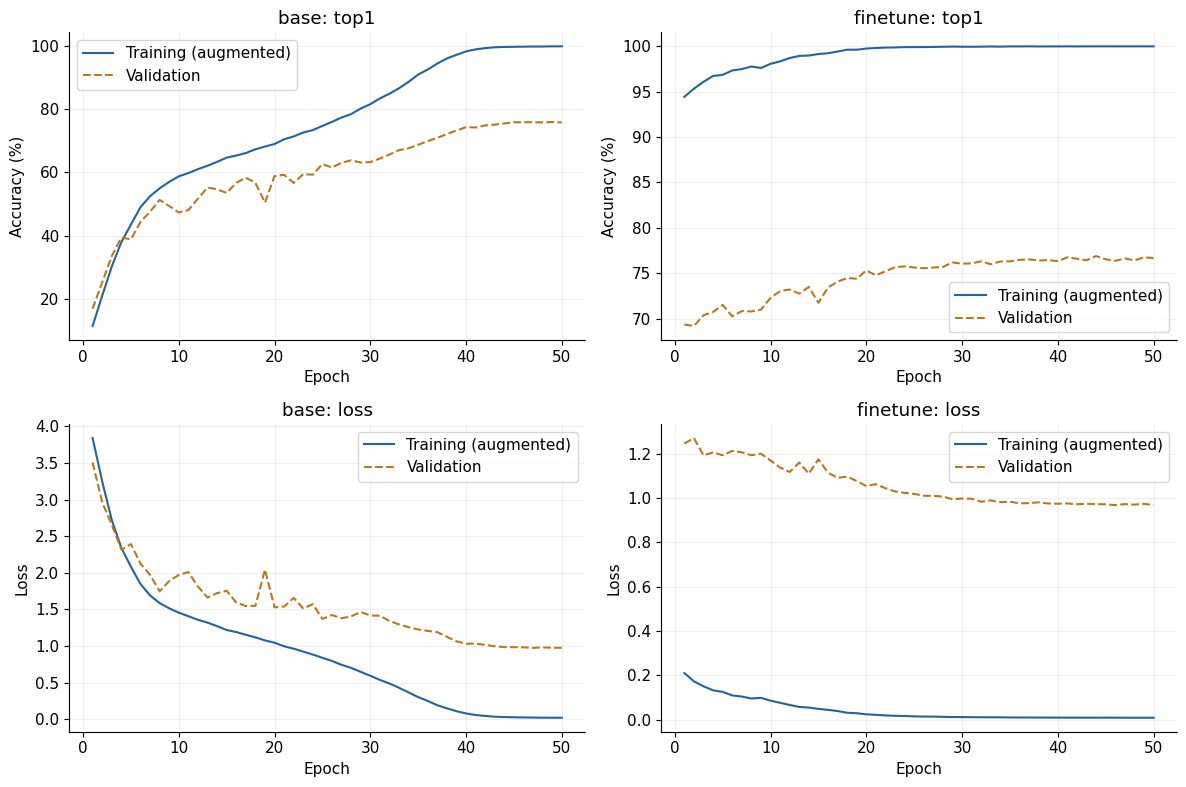

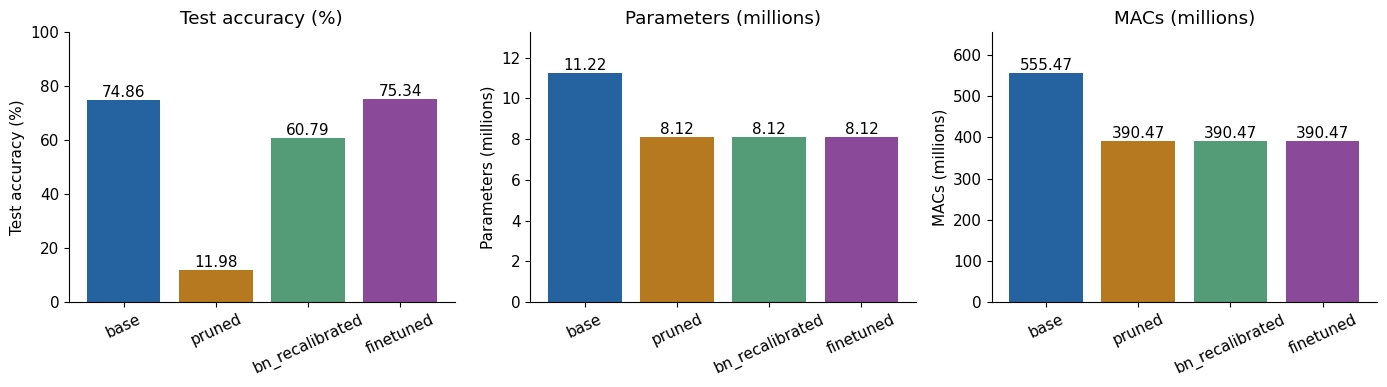

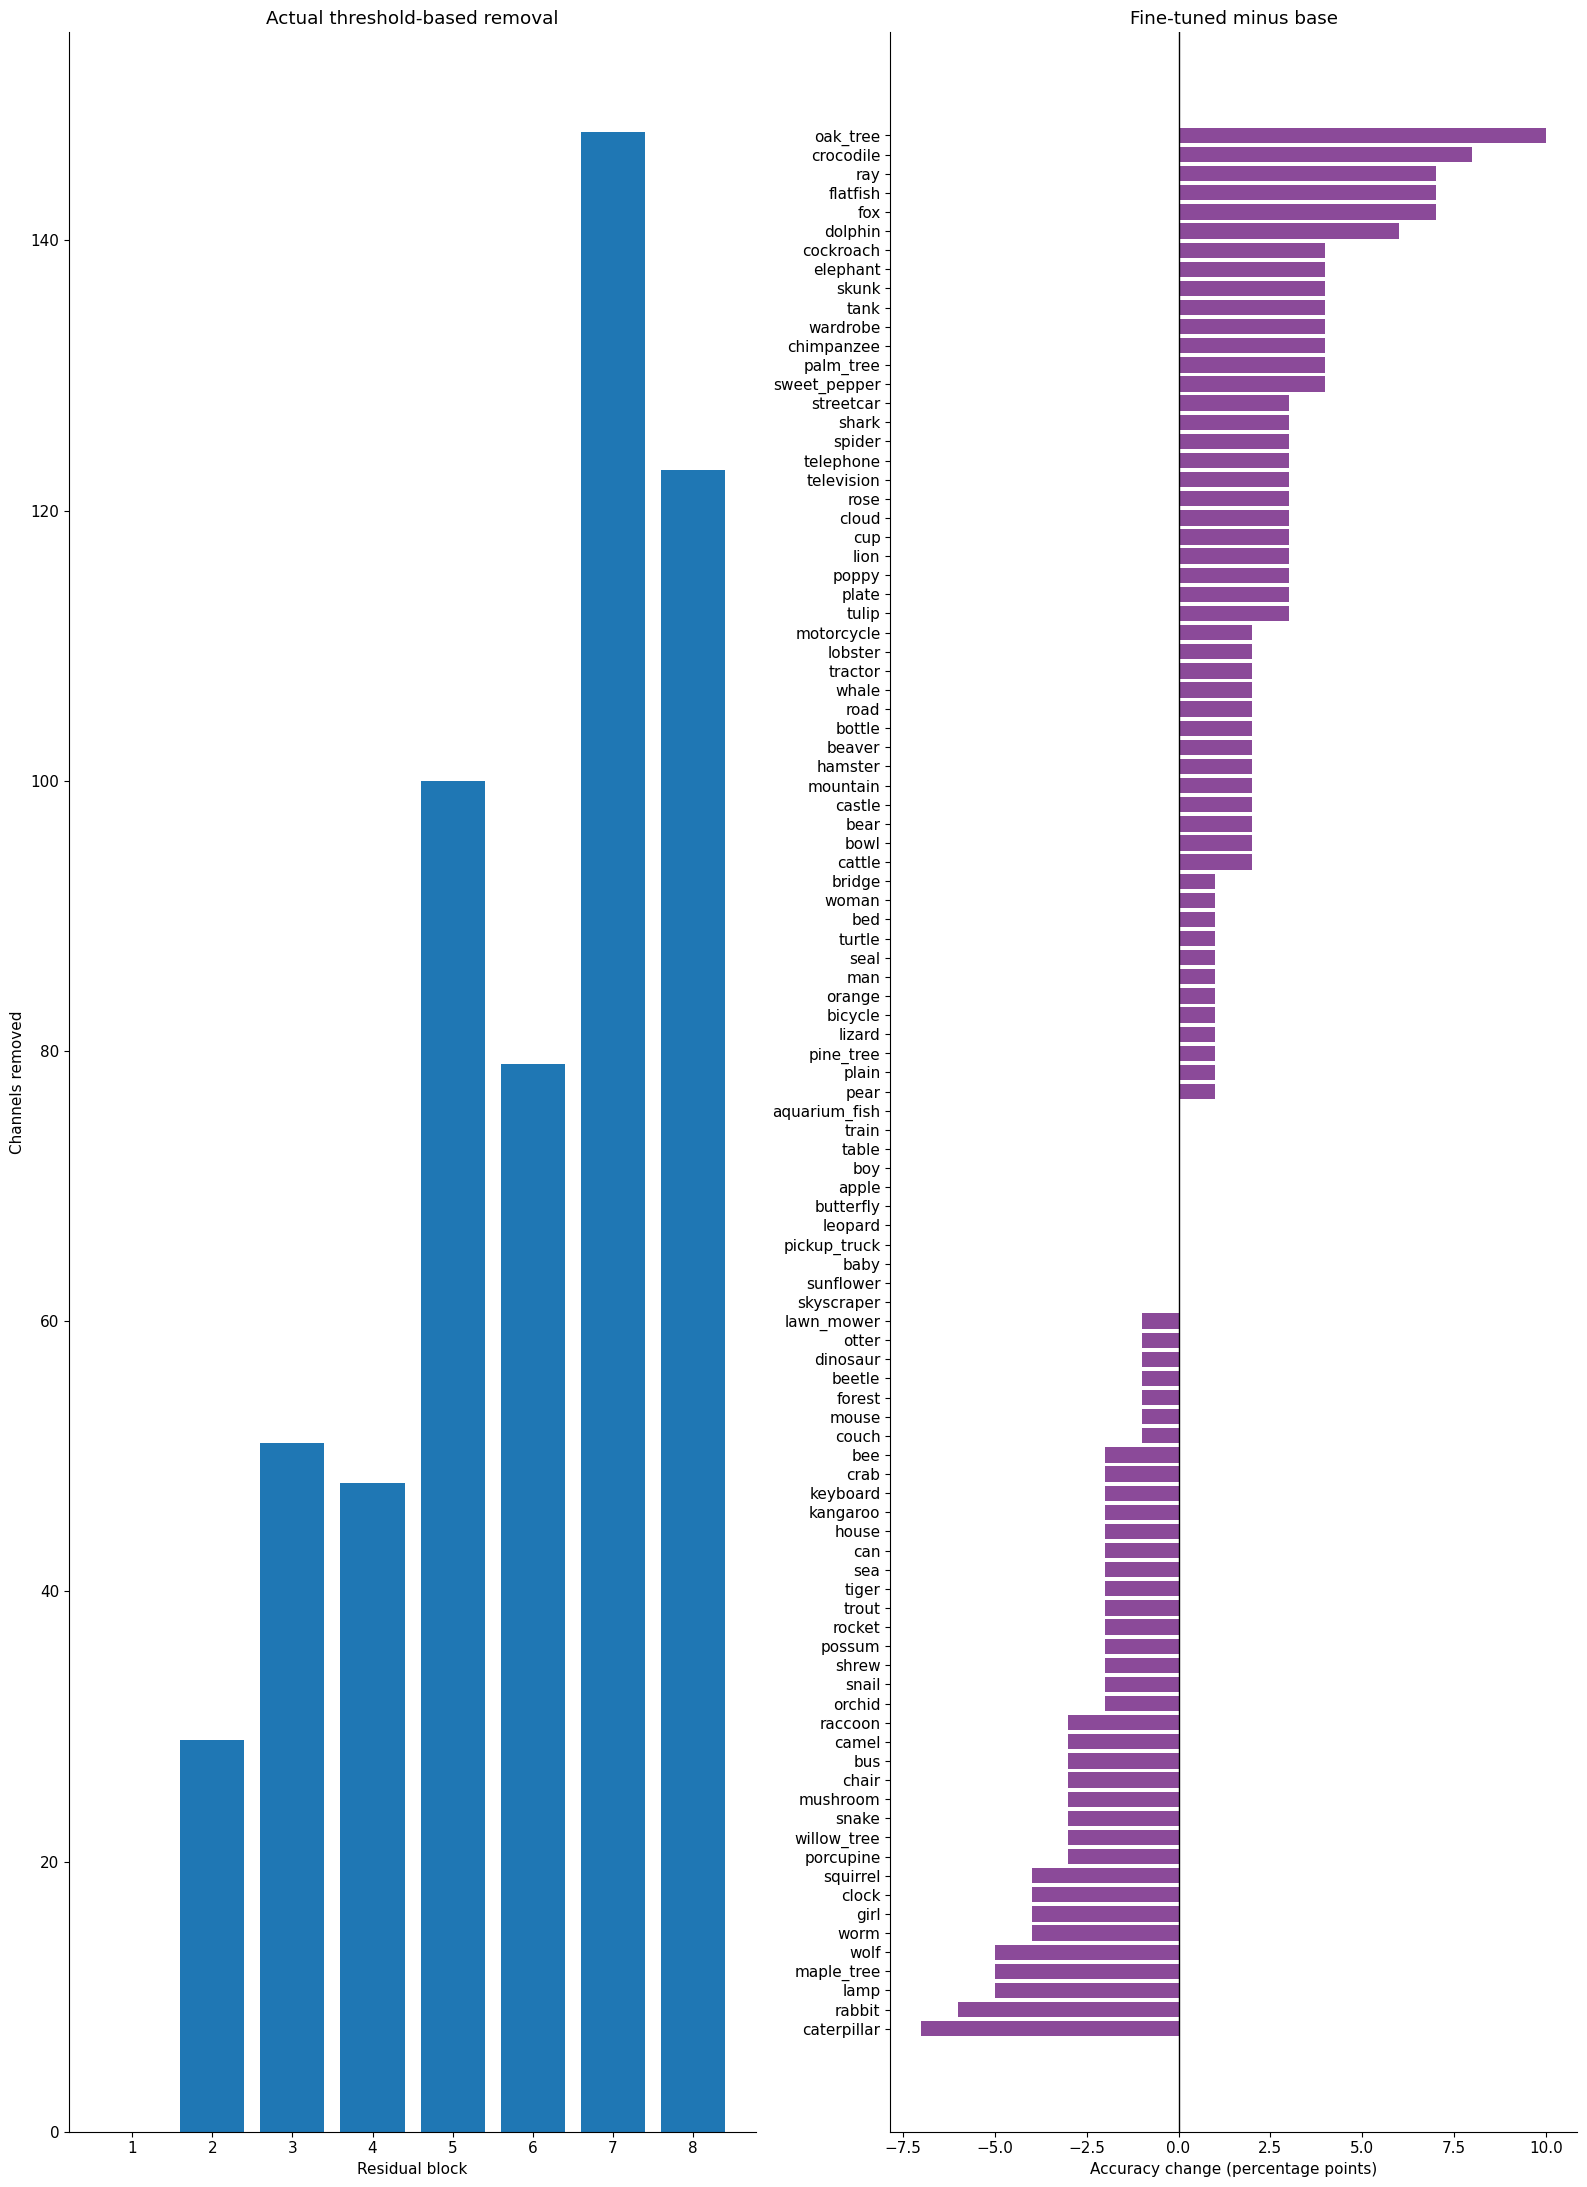

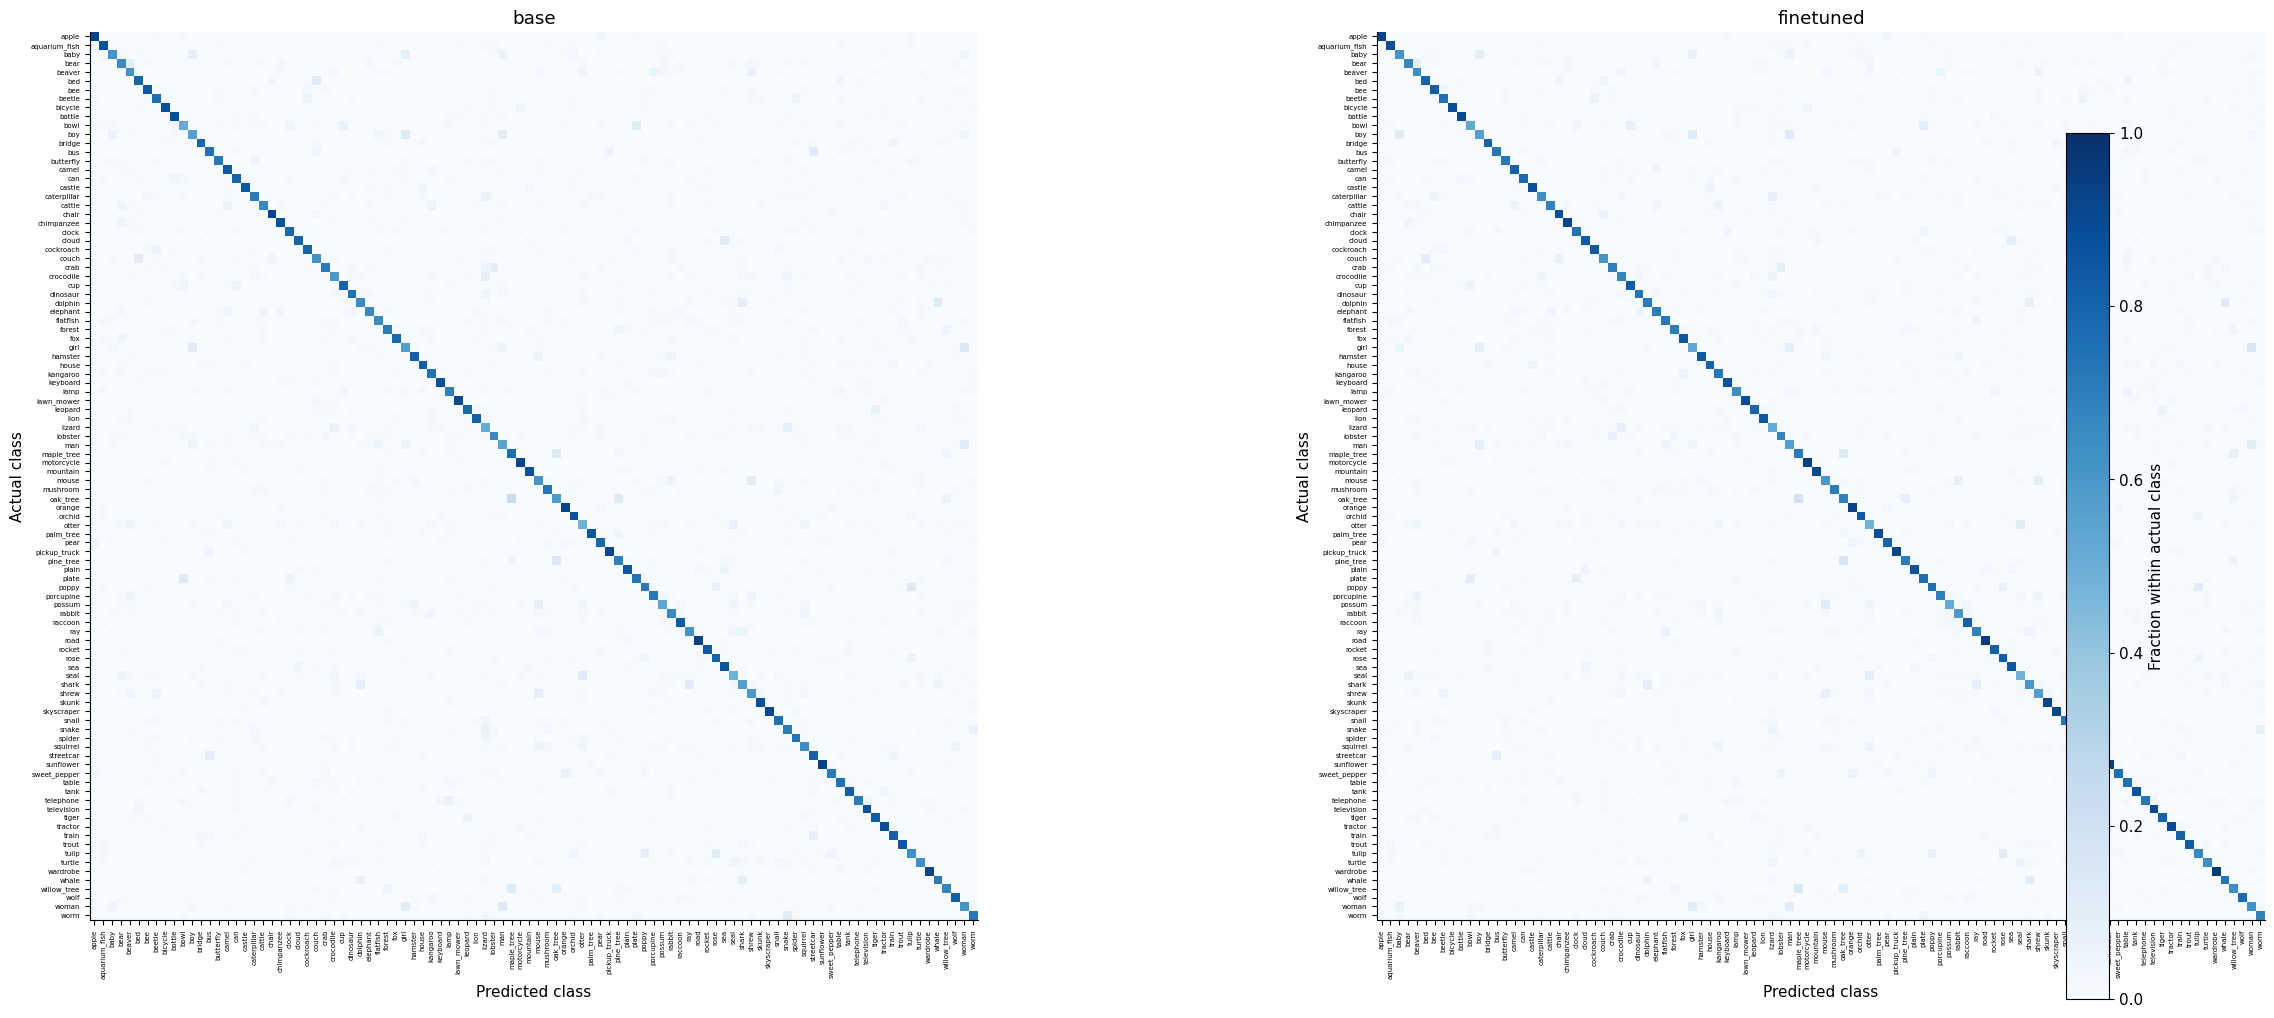

{
  "completed": true,
  "config": {
    "run_name": "freqprune_resnet18_c100_avgabs_r3_sim095_seed42_50plus50_v1",
    "seed": 42,
    "base_epochs": 50,
    "finetune_epochs": 50,
    "batch_size": 128,
    "eval_batch_size": 256,
    "num_workers": 2,
    "base_lr": 0.1,
    "finetune_lr": 0.01,
    "warmup_epochs": 5,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "nmf_rank": 3,
    "similarity_threshold": 0.95,
    "nmf_max_iter": 5000,
    "nmf_retry_max_iter": 20000,
    "nmf_tolerance": 0.0001,
    "signed_cosine_min": 0.2,
    "relative_bias_max": 0.25,
    "validation_per_class": 50,
    "bn_calibration_per_class": 50,
    "amp": true,
    "resume": true,
    "save_to_drive": true,
    "download_models": true
  },
  "channels_removed": 578,
  "eligible_channel_reduction_percent": 30.104166666666668,
  "base_test_top1": 74.86,
  "pruned_test_top1": 11.98,
  "finetuned_test_top1": 75.34,
  "test_accuracy_drop_pp": -0.480000000000004,
  "validation_accuracy_drop_pp": -0.97

In [ ]:
plots=RUN_DIR/"plots"; plots.mkdir(exist_ok=True)
fig,axes=plt.subplots(2,2,figsize=(12,8))
for column,stage in enumerate(["base","finetune"]):
    history=pd.read_csv(RUN_DIR/stage/"history.csv")
    for row,metric in enumerate(["top1","loss"]):
        ax=axes[row,column]
        ax.plot(history.epoch,history[f"train_{metric}"],label="Training (augmented)",color="#2463A0")
        ax.plot(history.epoch,history[f"validation_{metric}"],label="Validation",color="#B7791F",linestyle="--")
        ax.set(xlabel="Epoch",ylabel="Accuracy (%)" if metric=="top1" else "Loss",title=f"{stage}: {metric}")
        ax.grid(alpha=.2); ax.legend()
fig.tight_layout(); fig.savefig(plots/"learning_curves.png",dpi=160); plt.show()
fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,metric,divisor,label in zip(axes,["test_top1","parameters","macs"],[1,1e6,1e6],
                                 ["Test accuracy (%)","Parameters (millions)","MACs (millions)"]):
    bars=ax.bar(results.stage,results[metric]/divisor,color=["#2463A0","#B7791F","#549B77","#8B4A99"])
    ax.set(ylabel=label,title=label); ax.tick_params(axis="x",rotation=25); ax.bar_label(bars,fmt="%.2f")
    if metric=="test_top1": ax.set_ylim(0,100)
    else: ax.set_ylim(0,float((results[metric]/divisor).max())*1.18)
fig.tight_layout(); fig.savefig(plots/"stage_comparison.png",dpi=160); plt.show()
fig,axes=plt.subplots(1,2,figsize=(16,22))
axes[0].bar(layer_results.block,layer_results.removed_channels)
axes[0].set(xlabel="Residual block",ylabel="Channels removed",title="Actual threshold-based removal")
ordered=class_results.sort_values("finetuned_minus_base_pp")
axes[1].barh(ordered["class"],ordered.finetuned_minus_base_pp,color="#8B4A99")
axes[1].axvline(0,color="black",linewidth=1)
axes[1].set(xlabel="Accuracy change (percentage points)",title="Fine-tuned minus base")
fig.tight_layout(); fig.savefig(plots/"pruning_and_classes.png",dpi=160); plt.show()
fig,axes=plt.subplots(1,2,figsize=(30,15))
for ax,stage in zip(axes,["base","finetuned"]):
    confusion=pd.read_csv(RUN_DIR/f"{stage}_confusion.csv",index_col=0).to_numpy()
    im=ax.imshow(confusion/np.maximum(confusion.sum(axis=1,keepdims=True),1),vmin=0,vmax=1,cmap="Blues")
    ax.set(xticks=range(100),yticks=range(100),xticklabels=CLASSES,yticklabels=CLASSES,
           xlabel="Predicted class",ylabel="Actual class",title=stage)
    ax.tick_params(axis="x",rotation=90,labelsize=5)
    ax.tick_params(axis="y",labelsize=5)
fig.colorbar(im,ax=axes.ravel().tolist(),label="Fraction within actual class",shrink=.75)
fig.subplots_adjust(bottom=.23,wspace=.45,right=.85)
fig.savefig(plots/"confusion_matrices.png",dpi=160,bbox_inches="tight"); plt.show()
by_stage=results.set_index("stage"); base=by_stage.loc["base"]; final=by_stage.loc["finetuned"]
summary={"completed":True,"config":CONFIG,"channels_removed":removed,
    "eligible_channel_reduction_percent":100*removed/int(layer_results.original_channels.sum()),
    "base_test_top1":float(base.test_top1),"pruned_test_top1":float(by_stage.loc["pruned","test_top1"]),
    "finetuned_test_top1":float(final.test_top1),"test_accuracy_drop_pp":float(base.test_top1-final.test_top1),
    "validation_accuracy_drop_pp":float(base.validation_top1-final.validation_top1),
    "parameter_reduction_percent":100*(1-float(final.parameters/base.parameters)),
    "mac_reduction_percent":100*(1-float(final.macs/base.macs)),
    "base_training_seconds":float(sum(r["seconds"] for r in base_history)),
    "finetuning_seconds":float(sum(r["seconds"] for r in finetune_history)),
    "nonconverged_blocks":layer_results.loc[~layer_results.converged.astype(bool),"block"].astype(int).tolist(),
    "limitations":["One seed", "No matched random/magnitude pruning baseline",
                   "Similarity and signed-weight thresholds are experimental", "Only internal conv1 channels are eligible",
                   "GPU timings are specific to this hardware, precision and backend settings"]}
for batch in [1,128]:
    measured=speeds[speeds.batch_size==batch].set_index("stage")
    summary[f"speedup_batch{batch}"]=float(measured.loc["base","median_ms"]/measured.loc["finetuned","median_ms"])
write_json(summary,RUN_DIR/"summary.json")
print(json.dumps(summary,indent=2))
print(f"Test accuracy: {base.test_top1:.2f}% -> {final.test_top1:.2f}%.")
print(f"Parameters reduced by {summary['parameter_reduction_percent']:.2f}%; MACs by {summary['mac_reduction_percent']:.2f}%.")
print("Speedup above 1 means faster; below 1 means slower. Report measured speed separately from MAC savings.")
write_json({"stage":"results_complete","complete":True},RUN_DIR/"status.json")

## 16. Save a portable model package and download it
The package contains the trained base model, fine-tuned model, model-definition code, settings and summary.
Full resumable checkpoints and all analysis files remain in Drive; the notebook snapshot is also saved when Colab allows it.

In [ ]:
package=RUN_DIR/"download_package"; package.mkdir(exist_ok=True)
for name in ["base_model.pt","finetuned_model.pt","config.json","dataset.json","summary.json","results.csv","layer_pruning.csv"]:
    shutil.copy2(RUN_DIR/name,package/name)
definition='import torch\nfrom torch import nn\n\nclass BasicBlock(nn.Module):\n    def __init__(self, inputs, outputs, hidden, stride=1):\n        super().__init__()\n        self.conv1 = nn.Conv2d(inputs, hidden, 3, stride=stride, padding=1, bias=False)\n        self.bn1 = nn.BatchNorm2d(hidden)\n        self.relu1 = nn.ReLU(inplace=False)\n        self.conv2 = nn.Conv2d(hidden, outputs, 3, padding=1, bias=False)\n        self.bn2 = nn.BatchNorm2d(outputs)\n        self.shortcut = nn.Identity() if stride == 1 and inputs == outputs else nn.Sequential(\n            nn.Conv2d(inputs, outputs, 1, stride=stride, bias=False), nn.BatchNorm2d(outputs))\n        self.relu2 = nn.ReLU(inplace=False)\n    def forward(self, x):\n        identity = self.shortcut(x)\n        out = self.relu1(self.bn1(self.conv1(x)))\n        return self.relu2(self.bn2(self.conv2(out)) + identity)\n\nclass ResNet18CIFAR(nn.Module):\n    def __init__(self, hidden_widths=None, num_classes=100, base_width=64):\n        super().__init__()\n        outputs = [base_width,base_width,2*base_width,2*base_width,\n                   4*base_width,4*base_width,8*base_width,8*base_width]\n        self.hidden_widths = list(outputs if hidden_widths is None else hidden_widths)\n        assert len(self.hidden_widths) == 8 and min(self.hidden_widths) >= 1\n        self.num_classes, self.base_width = num_classes, base_width\n        self.stem = nn.Sequential(nn.Conv2d(3,base_width,3,padding=1,bias=False),\n                                  nn.BatchNorm2d(base_width), nn.ReLU(inplace=False))\n        blocks, inputs = [], base_width\n        for index, (width,hidden) in enumerate(zip(outputs,self.hidden_widths)):\n            stride = 2 if index in (2,4,6) else 1\n            blocks.append(BasicBlock(inputs,width,hidden,stride)); inputs = width\n        self.blocks = nn.ModuleList(blocks)\n        self.pool = nn.AdaptiveAvgPool2d(1)\n        self.fc = nn.Linear(inputs,num_classes)\n        for module in self.modules():\n            if isinstance(module,nn.Conv2d):\n                nn.init.kaiming_normal_(module.weight,mode="fan_out",nonlinearity="relu")\n            elif isinstance(module,nn.BatchNorm2d):\n                nn.init.ones_(module.weight); nn.init.zeros_(module.bias)\n    def forward(self,x):\n        x = self.stem(x)\n        for block in self.blocks: x = block(x)\n        return self.fc(self.pool(x).flatten(1))\n    def architecture(self):\n        return {"hidden_widths":self.hidden_widths, "num_classes":self.num_classes, "base_width":self.base_width}\n'
(package/"model_definition.py").write_text(definition,encoding="utf-8")
reload_text="""import torch
from model_definition import ResNet18CIFAR

# Load only checkpoints you trust.
checkpoint = torch.load('finetuned_model.pt', map_location='cpu', weights_only=False)
model = ResNet18CIFAR(**checkpoint['architecture'])
model.load_state_dict(checkpoint['model_state_dict'], strict=True)
model.eval()
print('Model loaded. Normalize CIFAR-100 inputs using dataset.json.')
"""
(package/"load_model.py").write_text(reload_text,encoding="utf-8")
(package/"README.txt").write_text("Extract this ZIP, install torch, then run load_model.py.\n"
    "base_model.pt is the validation-best model from 50 base epochs.\n"
    "finetuned_model.pt is the validation-best model from 50 fine-tuning epochs.\n"
    "Training and validation indices, full logs and resumable checkpoints are in the Drive experiment folder.\n",encoding="utf-8")
try:
    from google.colab import _message
    snapshot=_message.blocking_request("get_ipynb",timeout_sec=30)["ipynb"]
    write_json(snapshot,RUN_DIR/"experiment_notebook.ipynb")
except Exception as error:
    print("Notebook remains saved in Colab; extra snapshot unavailable:",type(error).__name__)
archive=shutil.make_archive(str(SAVE_ROOT/(CONFIG["run_name"]+"_models")),"zip",root_dir=package)
print("Model package:",archive)
print("All results:",RUN_DIR)
write_json({"stage":"complete","complete":True,"model_package":archive},RUN_DIR/"status.json")
if CONFIG["download_models"]:
    from google.colab import files
    files.download(archive)
    print("Browser download requested. The ZIP also remains in Drive.")

Model package: /content/drive/MyDrive/FREQ_PRUNE_Experiments/freqprune_resnet18_c100_avgabs_r3_sim095_seed42_50plus50_v1_models.zip
All results: /content/drive/MyDrive/FREQ_PRUNE_Experiments/freqprune_resnet18_c100_avgabs_r3_sim095_seed42_50plus50_v1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Browser download requested. The ZIP also remains in Drive.
